# 03 EnKF Ensemble -- CI Band Visualization

Custom NumPy sequential data assimilation (offline/reanalysis EnKF).
WAM is the shared forecast background at every timestep; ensemble spread
comes from heteroscedastic process noise proportional to flow magnitude.

**Run this notebook from the `notebooks/` directory or the repo root:** `jupyter notebook`



In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("src"))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from red_tide_reanalysis.ingestion.obs_loader import load_observations
from red_tide_reanalysis.ingestion.wam_loader import load_wam_model
from red_tide_reanalysis.ingestion.align import align_obs_model
from red_tide_reanalysis.enkf.method import EnKFMethod
from red_tide_reanalysis.writers.ensemble_writer import write_ensemble_csv
from red_tide_reanalysis.writers.stats_writer import write_stats_csv

## 1. Load and Align Data

In [2]:
obs_raw = load_observations("input/Arcadia_Unified_TN_Reanalysis_2000_2023.csv")
wam_raw = load_wam_model("input/Station_02296750 (ARCADIA)_reach000084_83.csv")
obs, model = align_obs_model(obs_raw, wam_raw)
print(f"Aligned series: {len(obs)} timesteps, {obs.index[0].date()} to {obs.index[-1].date()}")

Aligned series: 787 timesteps, 2000-01-05 to 2023-12-07


## 2. Configure and Run EnKF

In [3]:
method = EnKFMethod(
    n_members=200,
    station_id="02296750_peace_river",
    sigma_q=0.10,
    r_alpha=0.10,
    inflation_factor=1.05,
    divergence_tol=0.001,
)
result = method.run(obs, model, n_members=200, seed=42)

print(f"EnKF configuration:")
print(f"  inflation_factor : {result.config['inflation_factor']}")
print(f"  sigma_q          : {result.config['sigma_q']}")
print(f"  r_alpha          : {result.config['r_alpha']}")
print(f"  divergence events: {result.config['divergence_events']}")
print(f"Ensemble shape: {result.members.shape}")

EnKF configuration:
  inflation_factor : 1.05
  sigma_q          : 0.1
  r_alpha          : 0.1
  divergence events: 0
Ensemble shape: (200, 787)


## 3. CI Band Visualization

5th-95th percentile shaded band from the 200-member EnKF ensemble.
Observations as scatter points; WAM model output as a continuous line.

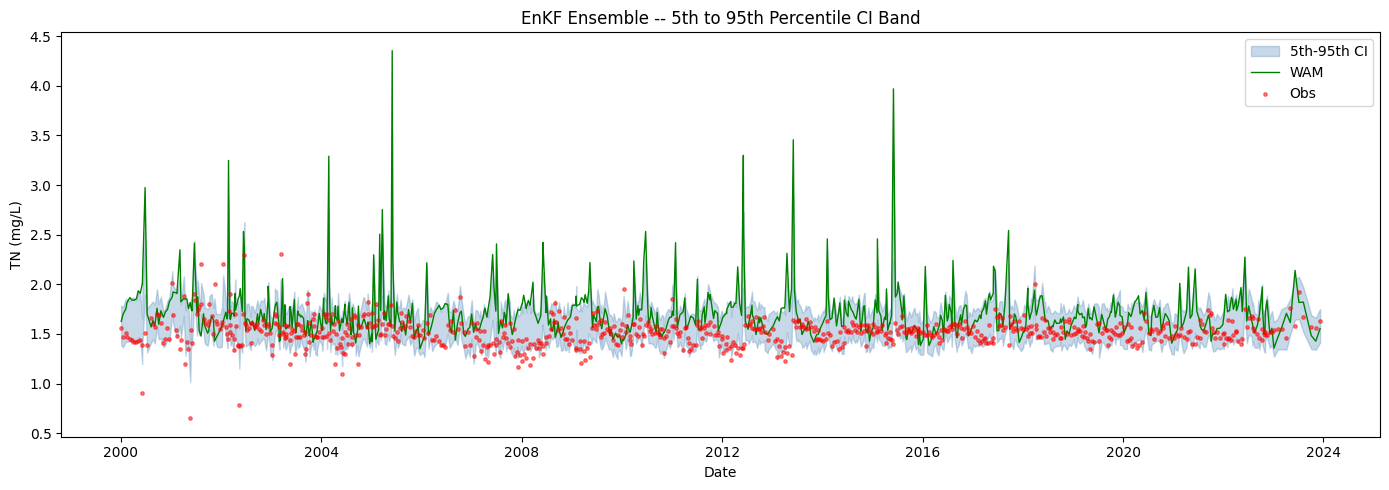

In [4]:
p5  = np.percentile(result.members, 5,  axis=0)
p95 = np.percentile(result.members, 95, axis=0)

fig, ax = plt.subplots(figsize=(14, 5))
ax.fill_between(result.time_index, p5, p95, alpha=0.3, color="steelblue", label="5th-95th CI")
ax.plot(result.time_index, result.model_output.values, color="green", linewidth=1.0, label="WAM")
ax.scatter(result.time_index, result.observations.values, s=6, color="red", alpha=0.5, label="Obs", zorder=5)
ax.set_xlabel("Date")
ax.set_ylabel("TN (mg/L)")
ax.set_title("EnKF Ensemble -- 5th to 95th Percentile CI Band")
ax.legend()
fig.tight_layout()
plt.show()

## 4. Export CSVs

In [5]:
output_dir = Path("output")
ens_path = write_ensemble_csv(result, output_dir / "ensembles")
stats_path = write_stats_csv(result, output_dir / "stats")
print(f"Ensemble CSV: {ens_path}")
print(f"Stats CSV:    {stats_path}")

Ensemble CSV: output\ensembles\enkf_02296750_peace_river_total_nitrogen_members.csv
Stats CSV:    output\stats\enkf_02296750_peace_river_total_nitrogen_stats.csv


## Summary

- Forward model: WAM as shared background forecast at every timestep (offline/reanalysis EnKF)
- Process noise: heteroscedastic, sigma_q * |WAM(t)|
- Observation error: heteroscedastic, r_alpha * max(|WAM(t)|, 0.05) mg/L floor
- Covariance inflation: inflation_factor = 1.05 applied pre-Kalman-gain
- Ensemble size: 200 members
- Output files: `output/ensembles/` and `output/stats/`